Using rolling maximum and min to create a ta upper and lower trigger system

In [ ]:
from sts.dio.equity import TickerDatabase as Ticker
from sts.stsig.ta.market_regime import TrendSupportResist
import plotly.io as pio
from sts.quant.candle import Candle
import os

saved file: ../../../data/market_data/equity/SPY.pkl


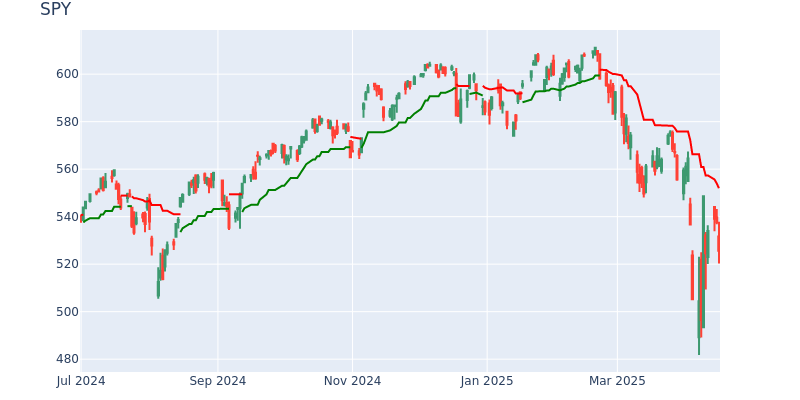

saved file: ../../../data/market_data/equity/QQQ.pkl


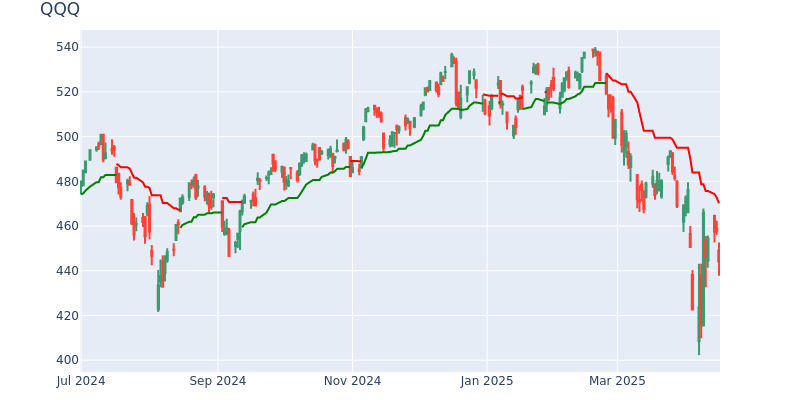

saved file: ../../../data/market_data/equity/IWM.pkl


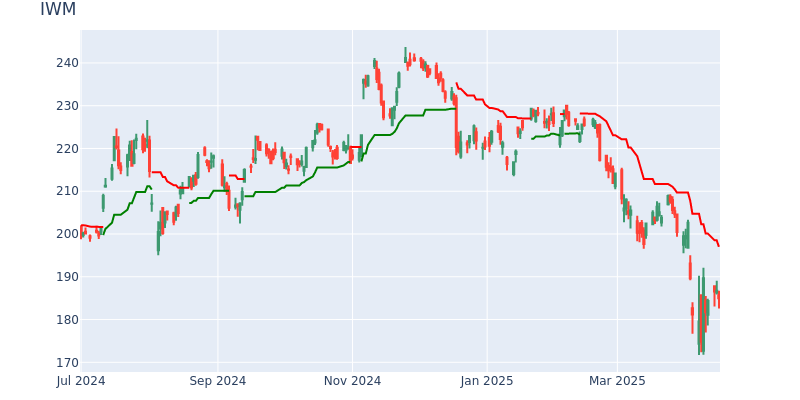

saved file: ../../../data/market_data/equity/GLD.pkl


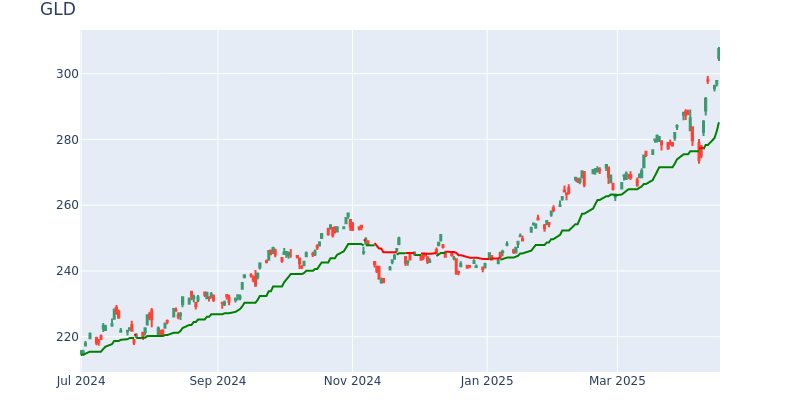

saved file: ../../../data/market_data/equity/SLV.pkl


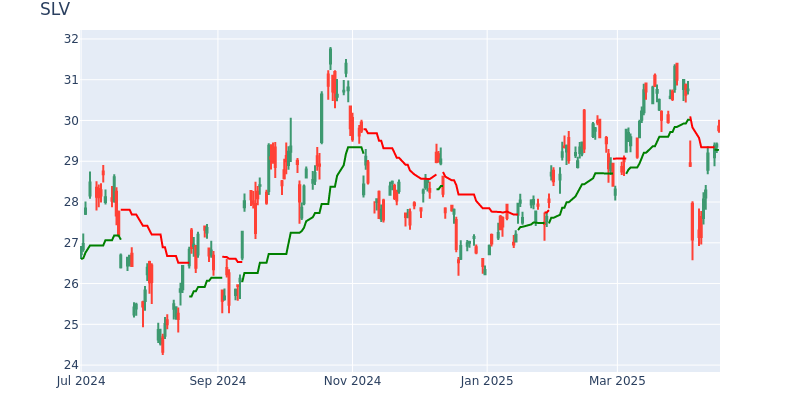

saved file: ../../../data/market_data/equity/CPER.pkl


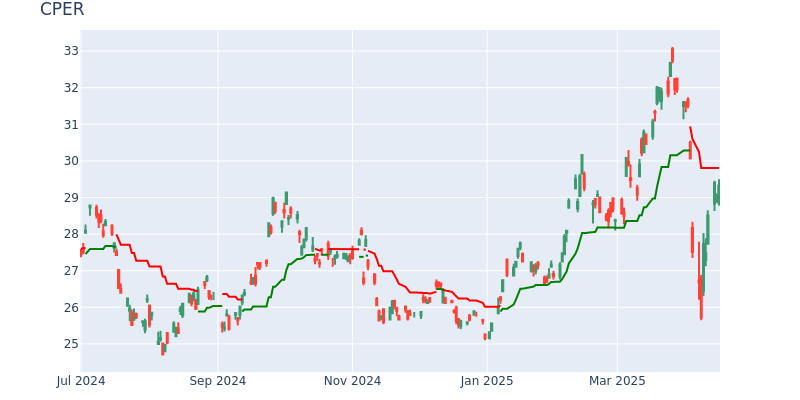

saved file: ../../../data/market_data/equity/USO.pkl


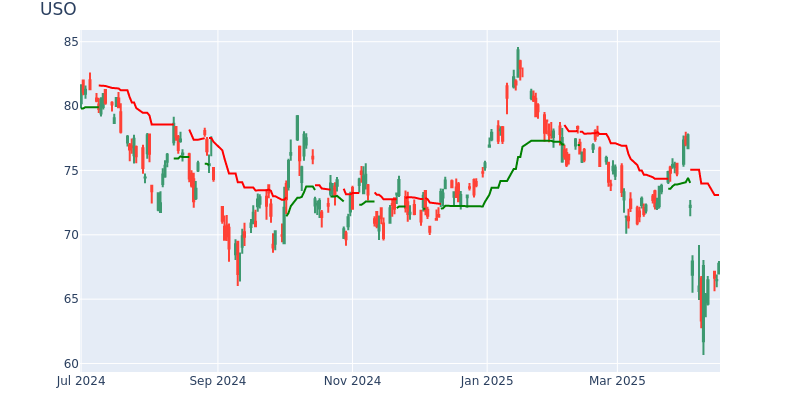

saved file: ../../../data/market_data/equity/TLT.pkl


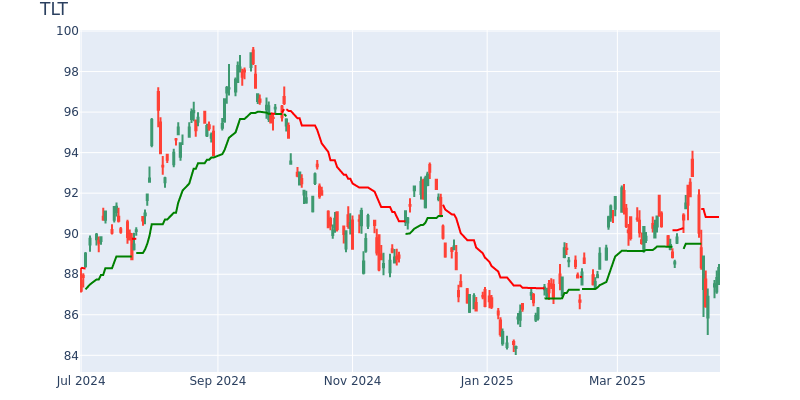

saved file: ../../../data/market_data/equity/KWEB.pkl


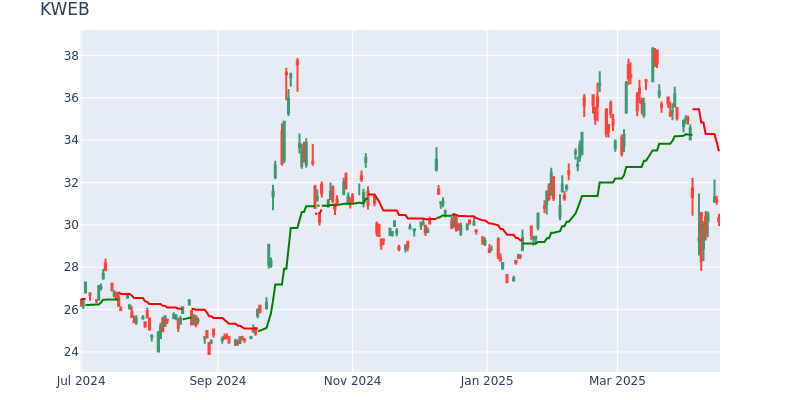

saved file: ../../../data/market_data/equity/PPA.pkl


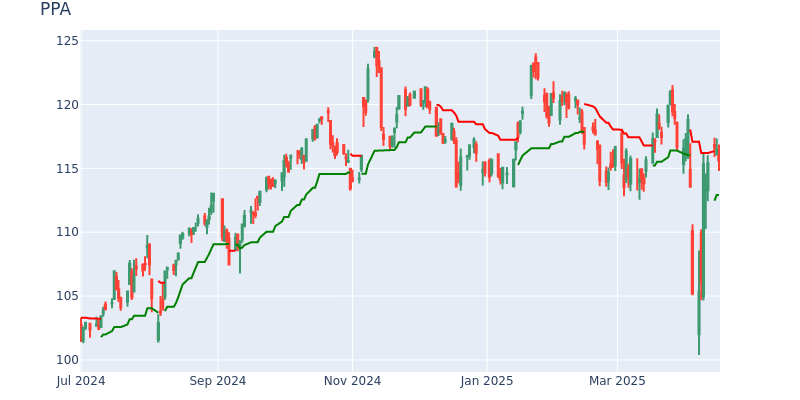

saved file: ../../../data/market_data/equity/IBIT.pkl


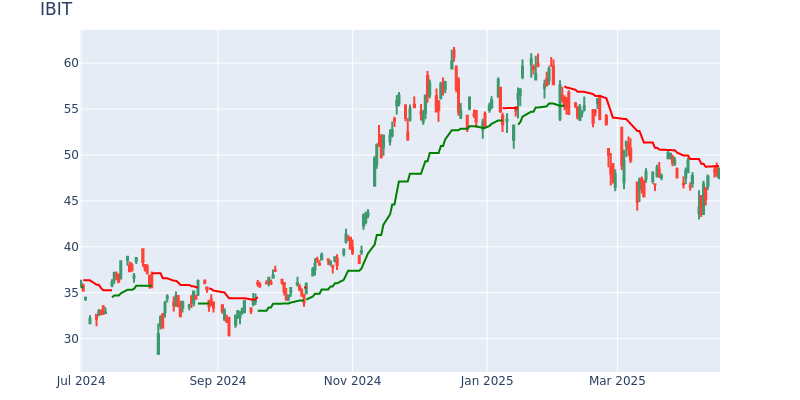

saved file: ../../../data/market_data/equity/XLF.pkl


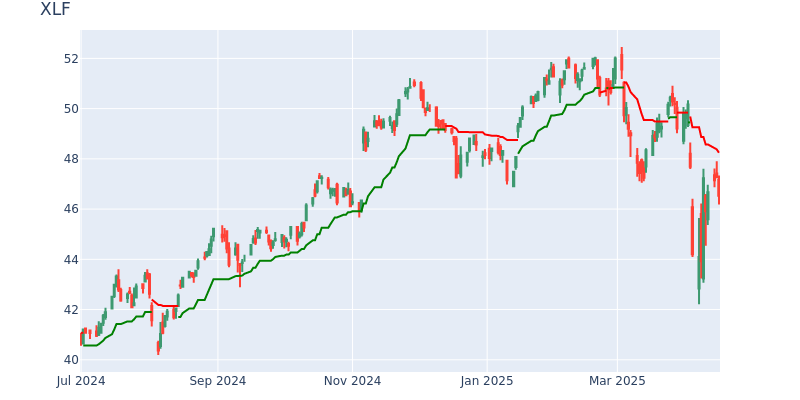

saved file: ../../../data/market_data/equity/XLI.pkl


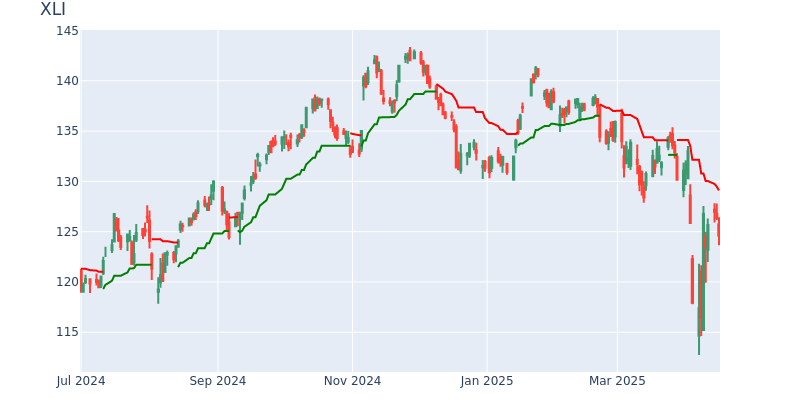

saved file: ../../../data/market_data/equity/XLB.pkl


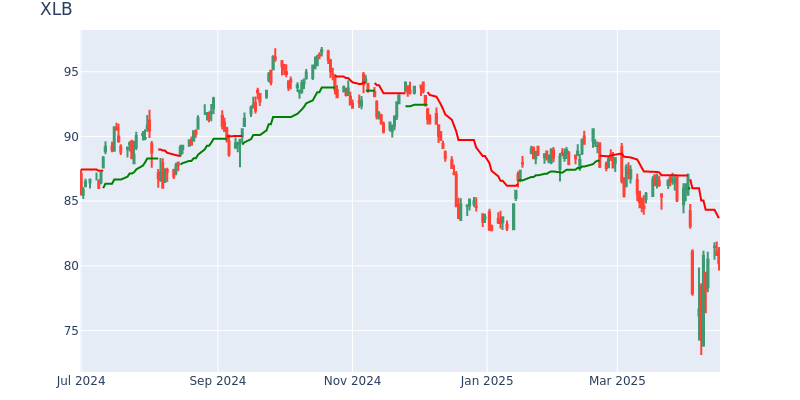

saved file: ../../../data/market_data/equity/XLC.pkl


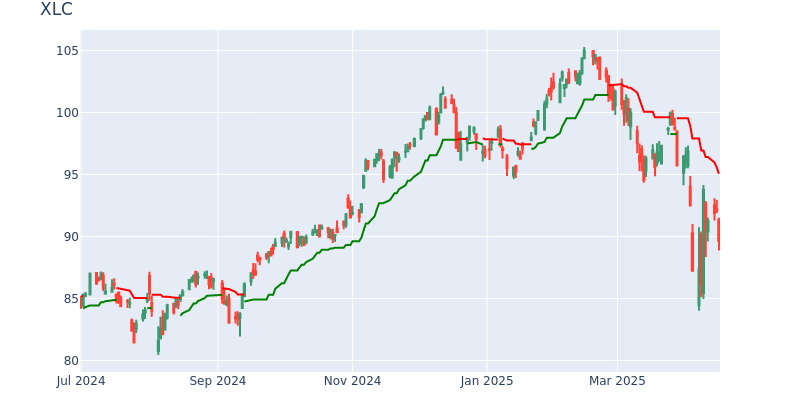

saved file: ../../../data/market_data/equity/XLY.pkl


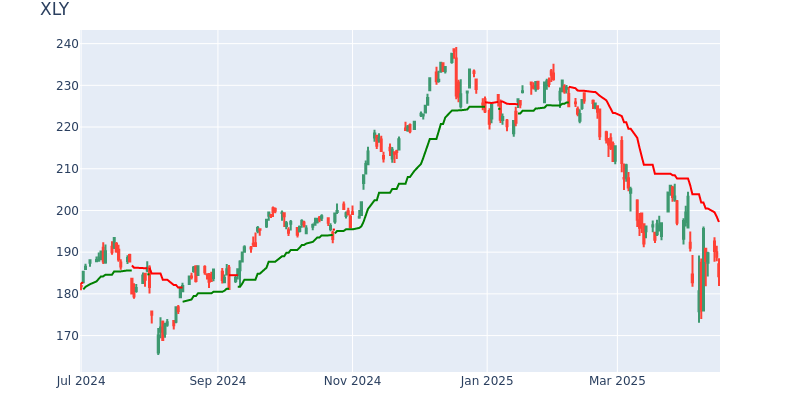

saved file: ../../../data/market_data/equity/XLP.pkl


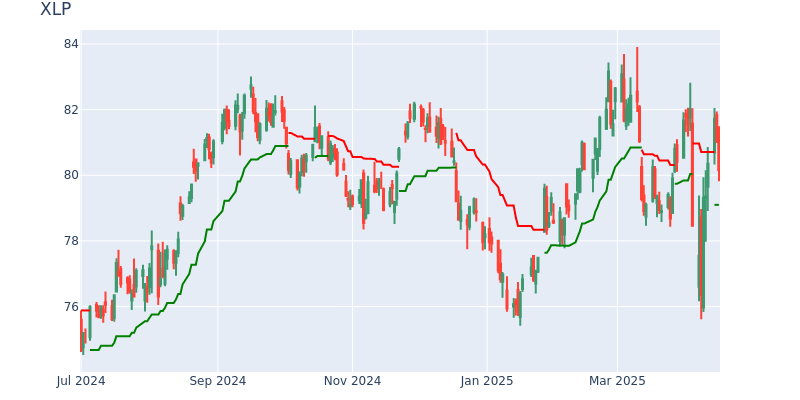

saved file: ../../../data/market_data/equity/XLV.pkl


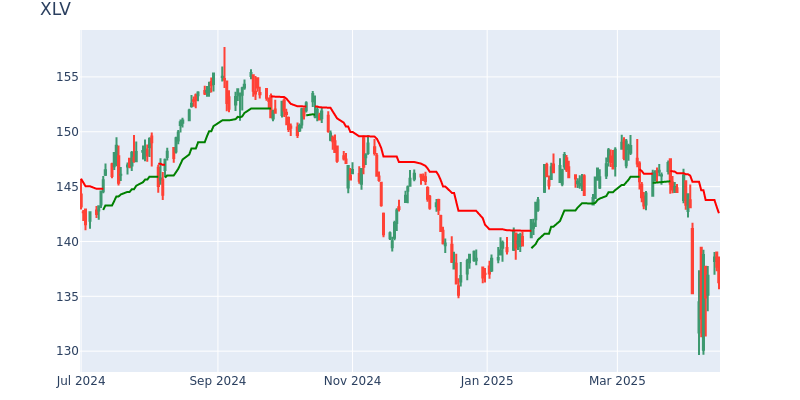

saved file: ../../../data/market_data/equity/XBI.pkl


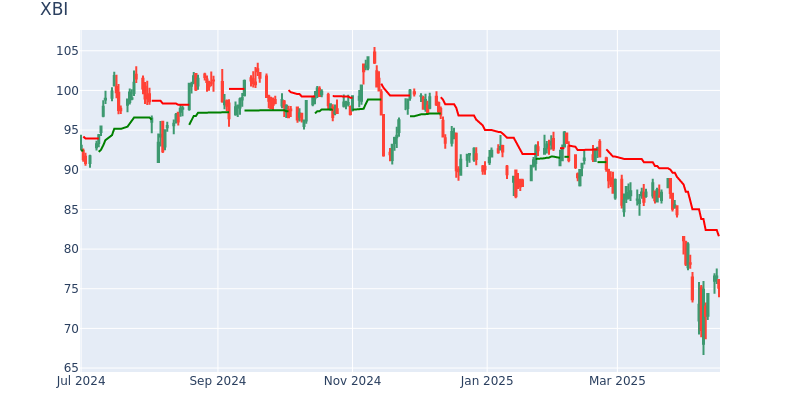

saved file: ../../../data/market_data/equity/XLK.pkl


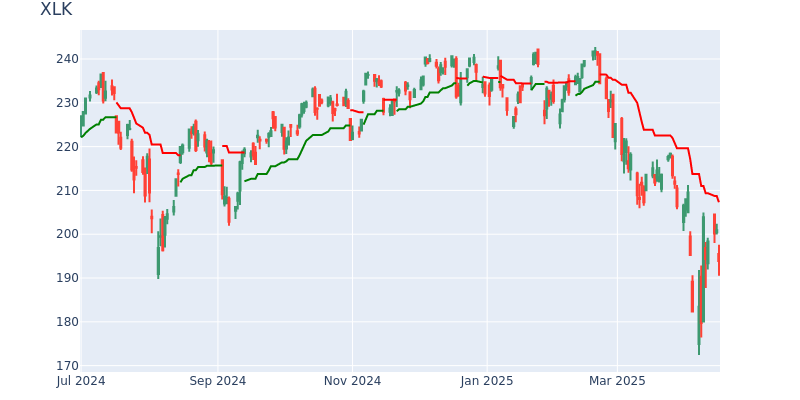

saved file: ../../../data/market_data/equity/XLU.pkl


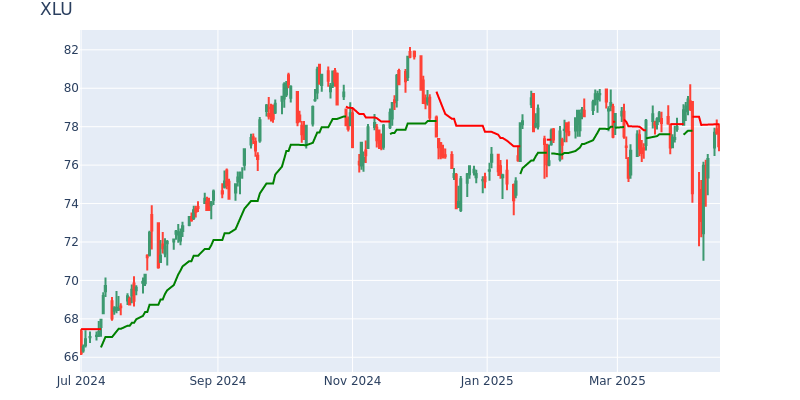

saved file: ../../../data/market_data/equity/XME.pkl


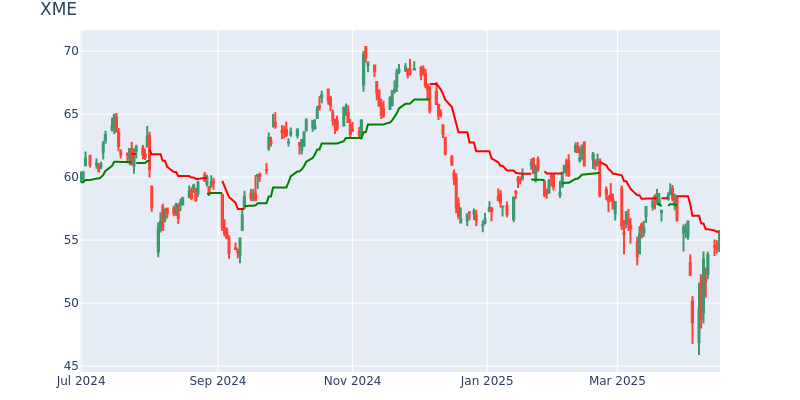

saved file: ../../../data/market_data/equity/MRVL.pkl


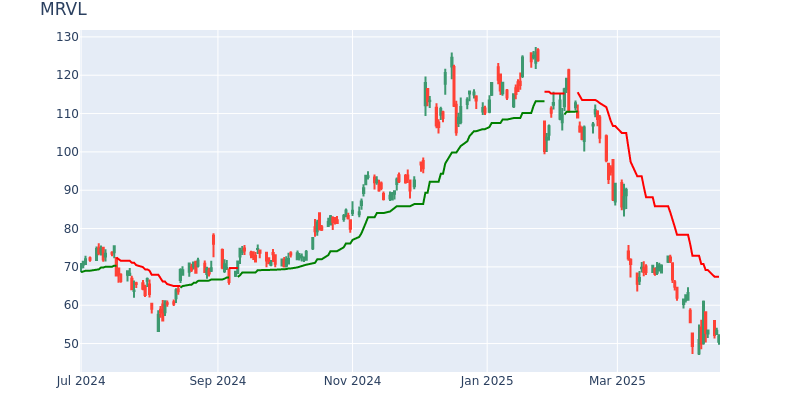

saved file: ../../../data/market_data/equity/ADBE.pkl


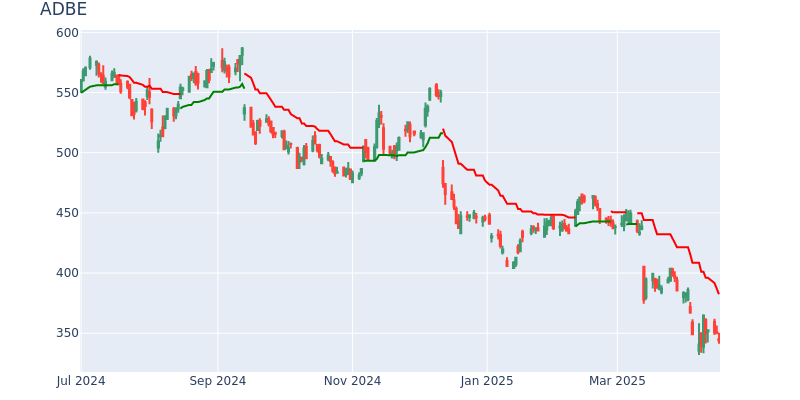

saved file: ../../../data/market_data/equity/ANET.pkl


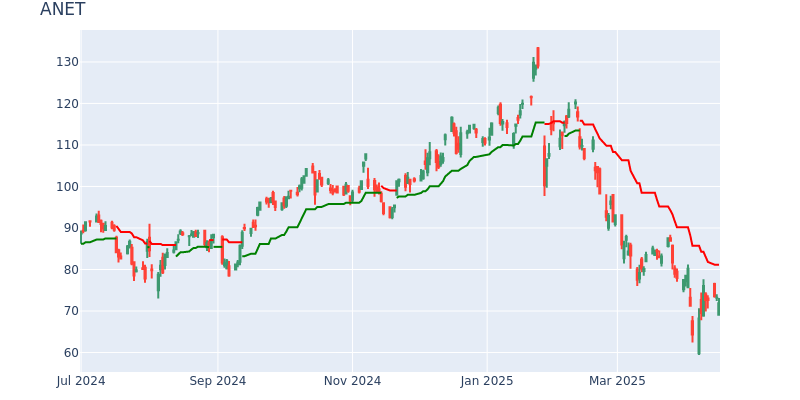

saved file: ../../../data/market_data/equity/PWR.pkl


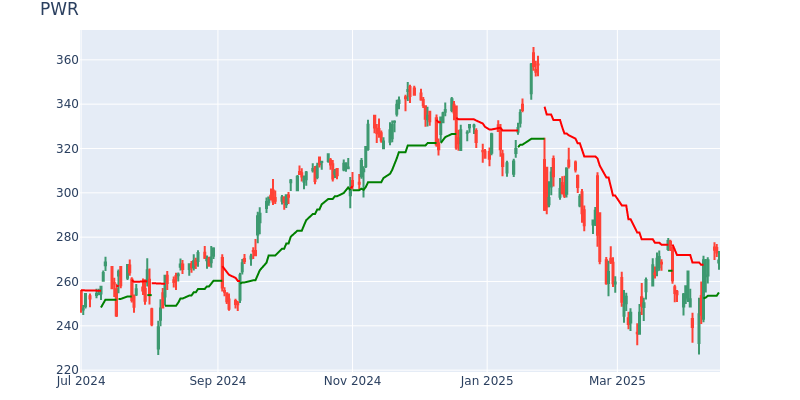

saved file: ../../../data/market_data/equity/AMD.pkl


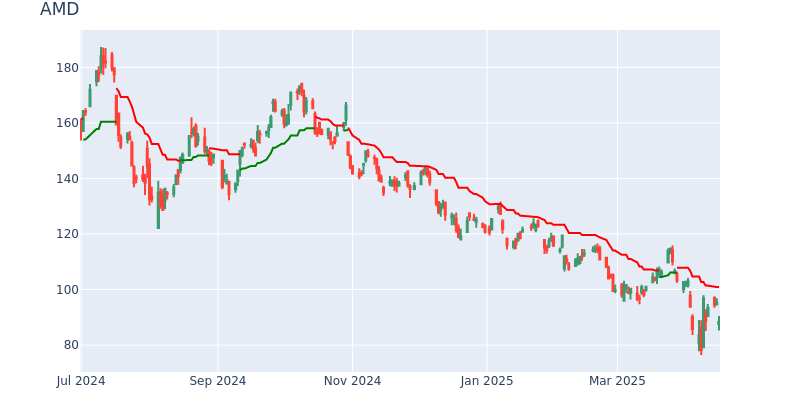

saved file: ../../../data/market_data/equity/GOOGL.pkl


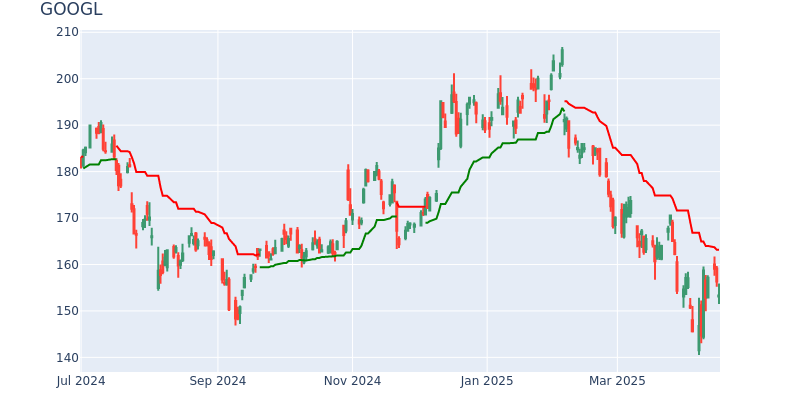

saved file: ../../../data/market_data/equity/NVDA.pkl


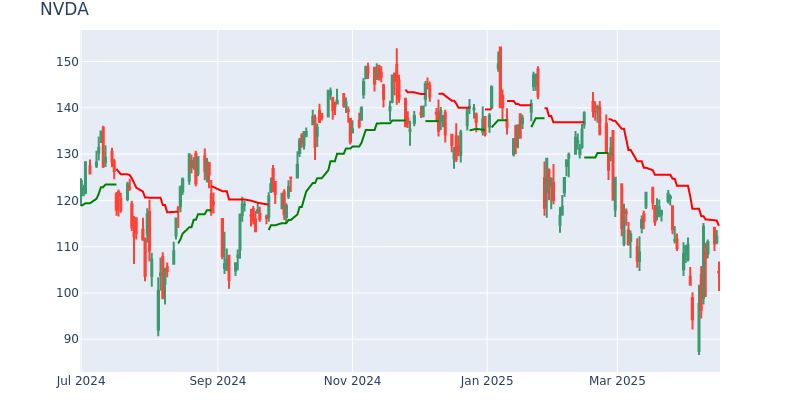

saved file: ../../../data/market_data/equity/META.pkl


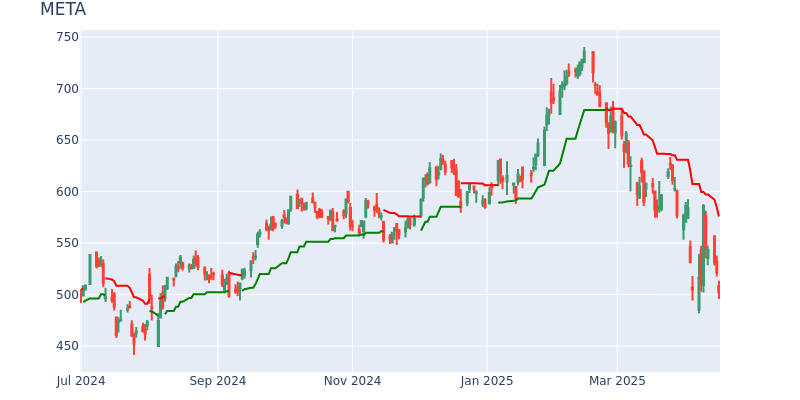

saved file: ../../../data/market_data/equity/ASML.pkl


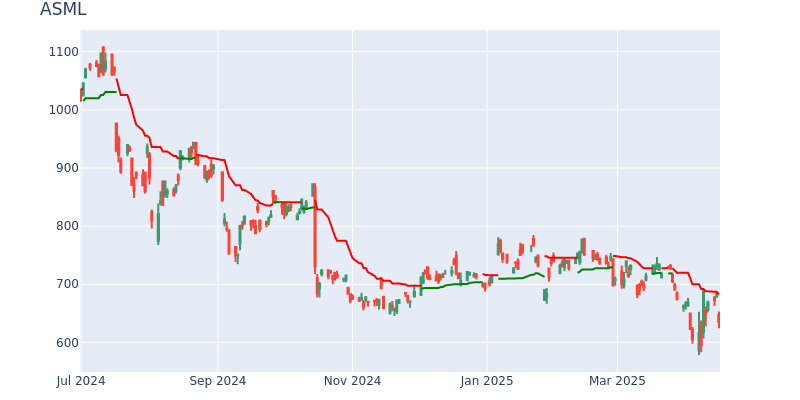

saved file: ../../../data/market_data/equity/TSLA.pkl


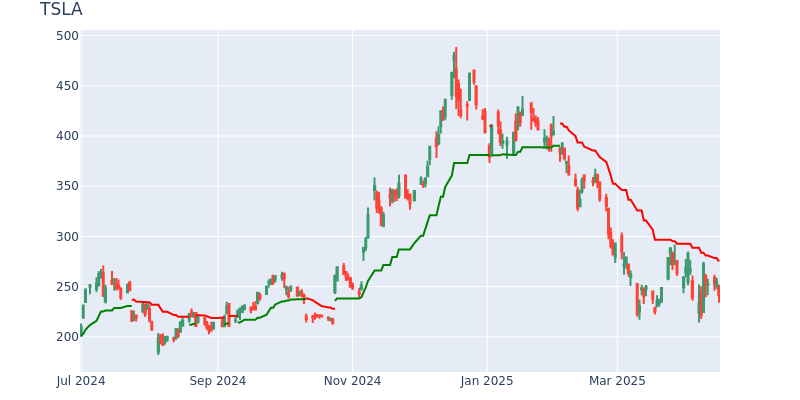

saved file: ../../../data/market_data/equity/PFE.pkl


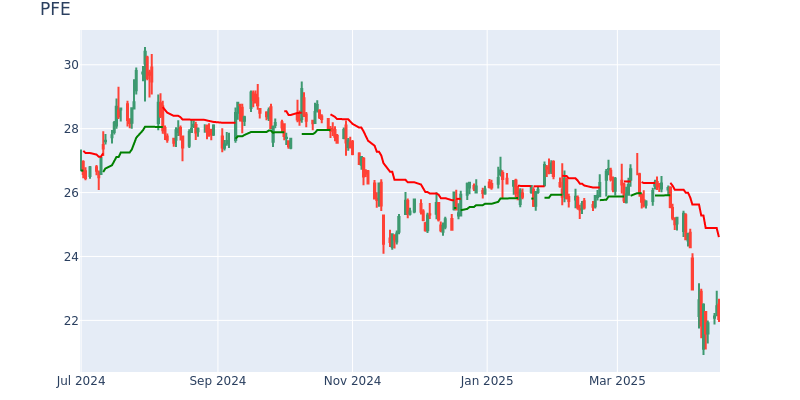

saved file: ../../../data/market_data/equity/IWM.pkl


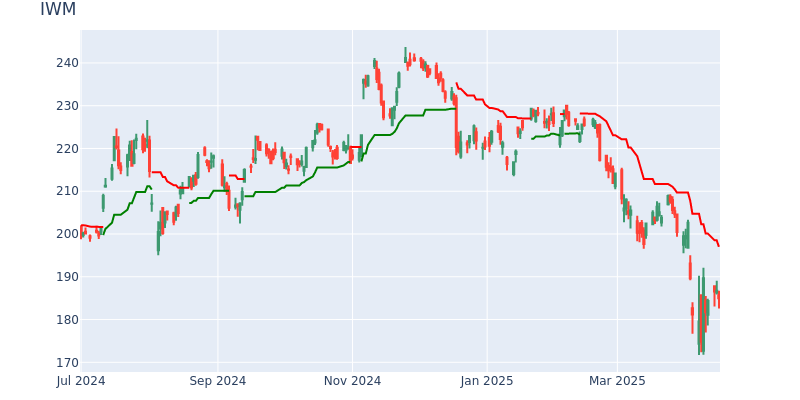

saved file: ../../../data/market_data/equity/AVGO.pkl


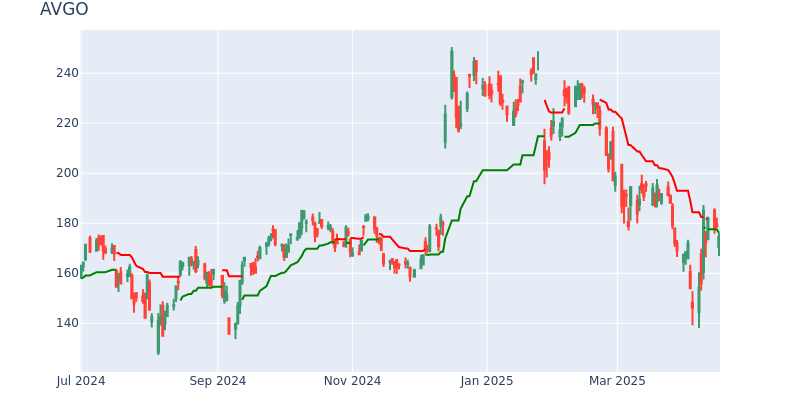

saved file: ../../../data/market_data/equity/FTNT.pkl


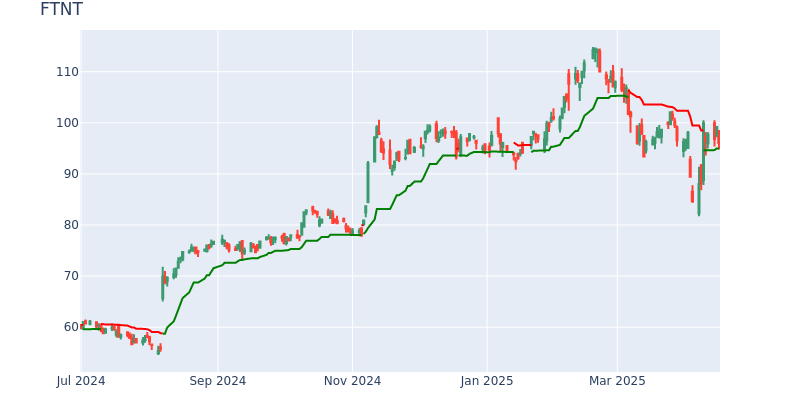

saved file: ../../../data/market_data/equity/MMM.pkl


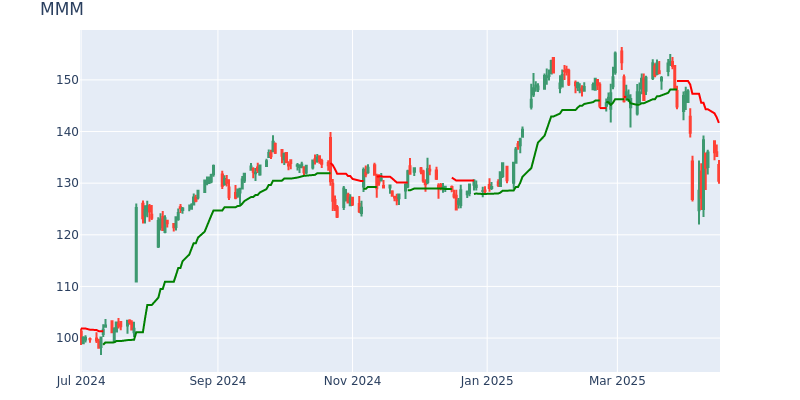

saved file: ../../../data/market_data/equity/TRV.pkl


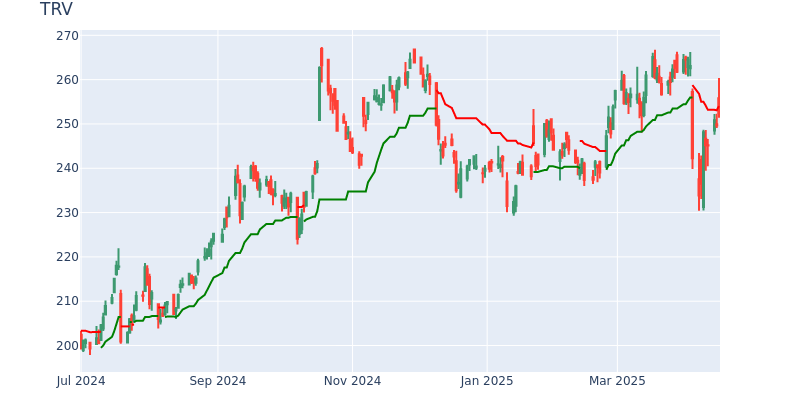

saved file: ../../../data/market_data/equity/LMT.pkl


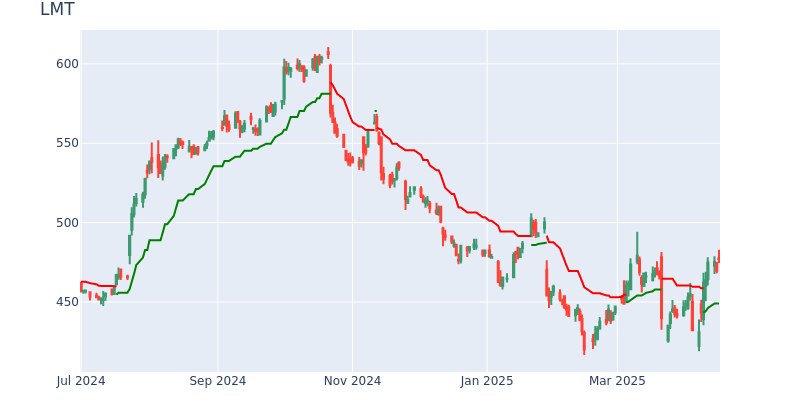

saved file: ../../../data/market_data/equity/JPY=X.pkl


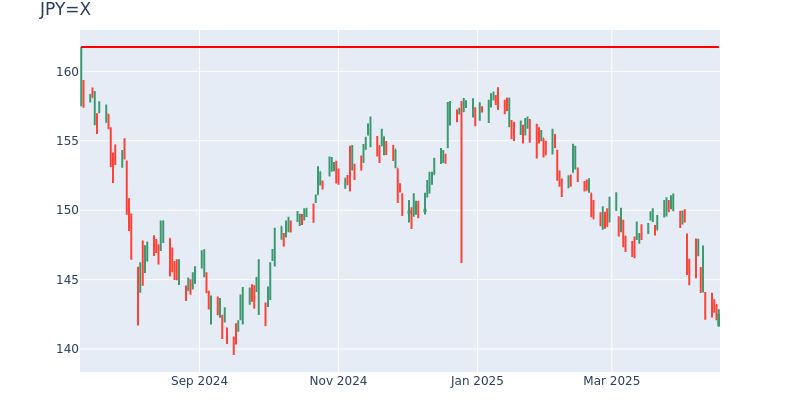

saved file: ../../../data/market_data/equity/GBPUSD=X.pkl


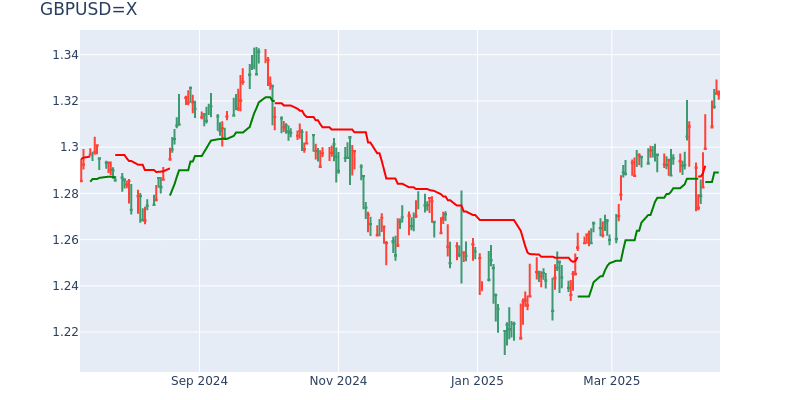

saved file: ../../../data/market_data/equity/AUDUSD=X.pkl


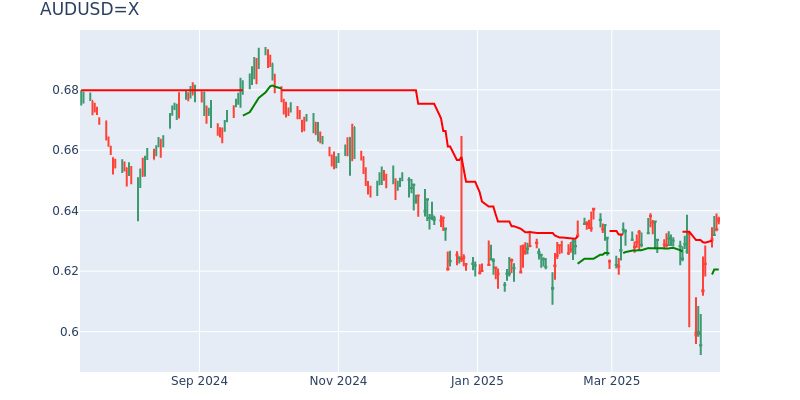

saved file: ../../../data/market_data/equity/EURUSD=X.pkl


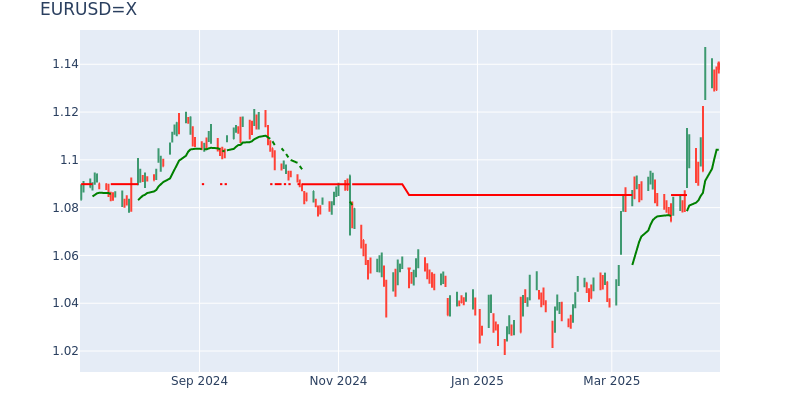

saved file: ../../../data/market_data/equity/CADUSD=X.pkl


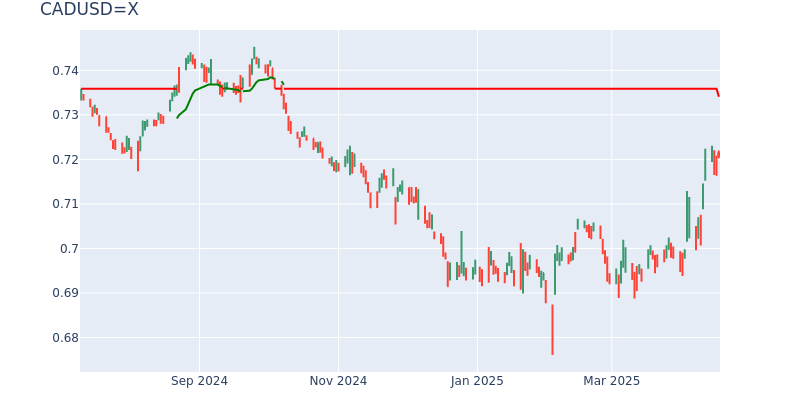

In [ ]:
pio.renderers.default = os.environ.get("PLOTLY_RENDERER", "png")
regime_dict = {}
resample_rule = "1D"
rule_period_map = {"1D": "2y", "1W": "10y", "1M": "10y"}
period = rule_period_map[resample_rule]
future = ["^SPX", "^NDX", "^RUT", "GC=F", "HG=F", "SI=F", "CL=F", "TLT", "KWEB"]
single_name = [
    "MRVL",
    "ADBE",
    "ANET",
    "PWR",
    "AMD",
    "GOOGL",
    "NVDA",
    "META",
    "ASML",
    "TSLA",
    "PFE",
    "IWM",
    "AVGO",
    "FTNT",
    "MMM",
    "TRV",
    "LMT",
]
etf = [
    "SPY",
    "QQQ",
    "IWM",
    "GLD",
    "SLV",
    "CPER",
    "USO",
    "TLT",
    "KWEB",
    "PPA",
    "IBIT",
    "XLF",
    "XLI",
    "XLB",
    "XLC",
    "XLY",
    "XLP",
    "XLV",
    "XBI",
    "XLK",
    "XLU",
    "XME",
]
fx = ["JPY=X", "GBPUSD=X", "AUDUSD=X", "EURUSD=X", "CADUSD=X"]
for sym in etf + single_name + fx:
    ticker = Ticker(sym)
    df = Candle(ticker.history(period=period))
    if resample_rule != "1D":
        df = df.resample(resample_rule)
    trend_support_resist = TrendSupportResist(halflife=5)
    trend_support_resist.set_data(df)
    fig = trend_support_resist.plot(trend_support_resist.df.iloc[-200:])
    fig.update_layout(title=sym, height=400, width=800, margin={"t": 30, "b": 20})
    fig.show()
    regime_dict[sym] = trend_support_resist